# Unified Dataset Preprocessing Analysis

This notebook analyzes the class distribution, bounding box statistics, and visualizes samples of the preprocessed joint HUTECH and UA-DETRAC dataset.

In [1]:
import os
import random
from collections import Counter
import cv2
import matplotlib.pyplot as plt

dataset_dir = '../dataset'
splits = ['train', 'valid', 'test']
target_classes = {0: 'motorbike', 1: 'car', 2: 'truck', 3: 'bus'}
class_colors = {
    0: (0, 255, 0),      # motorbike -> green
    1: (255, 0, 0),      # car -> blue
    2: (0, 0, 255),      # truck -> red
    3: (255, 255, 0)     # bus -> cyan
}

## 1. Class Distribution Analysis

In [2]:
stats = {}
for split in splits:
    lbl_dir = os.path.join(dataset_dir, split, 'labels')
    img_dir = os.path.join(dataset_dir, split, 'images')
    
    images = os.listdir(img_dir)
    labels = os.listdir(lbl_dir)
    
    class_counts = Counter()
    total_boxes = 0
    
    for fname in labels:
        if fname.endswith('.txt'):
            with open(os.path.join(lbl_dir, fname), 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        cls_id = int(parts[0])
                        class_counts[cls_id] += 1
                        total_boxes += 1
                        
    stats[split] = {
        'images': len(images),
        'total_boxes': total_boxes,
        'class_counts': class_counts
    }
    
    print(f'=== {split.upper()} SPLIT ===')
    print(f'Total Images: {len(images)}')
    print(f'Total Boxes: {total_boxes}')
    for cls_id in sorted(target_classes.keys()):
        count = class_counts.get(cls_id, 0)
        pct = (count / total_boxes * 100) if total_boxes > 0 else 0
        print(f'  {target_classes[cls_id]}: {count} ({pct:.2f}%)')

=== TRAIN SPLIT ===
Total Images: 7001
Total Boxes: 60234
  motorbike: 12467 (20.70%)
  car: 39992 (66.39%)
  truck: 1717 (2.85%)
  bus: 6058 (10.06%)
=== VALID SPLIT ===
Total Images: 506
Total Boxes: 4620
  motorbike: 2677 (57.94%)
  car: 1625 (35.17%)
  truck: 241 (5.22%)
  bus: 77 (1.67%)
=== TEST SPLIT ===
Total Images: 507
Total Boxes: 4574
  motorbike: 2635 (57.61%)
  car: 1610 (35.20%)
  truck: 250 (5.47%)
  bus: 79 (1.73%)


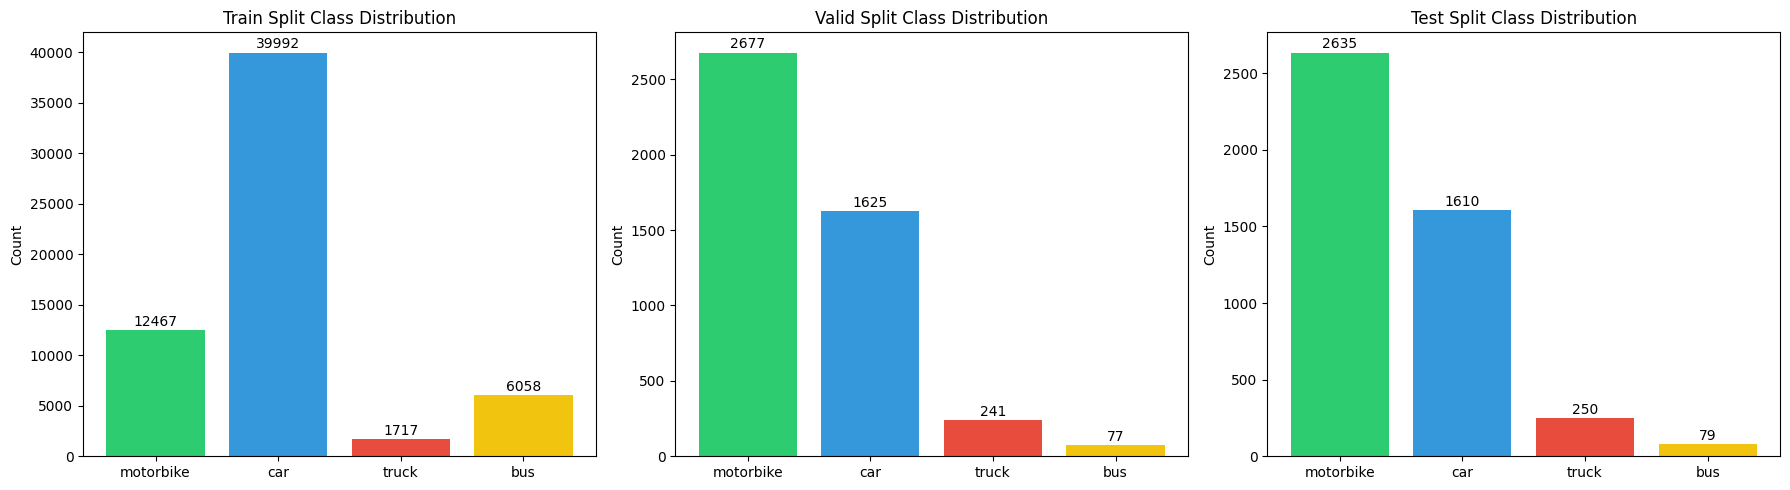

In [3]:
# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, split in enumerate(splits):
    class_counts = stats[split]['class_counts']
    counts = [class_counts.get(cls_id, 0) for cls_id in sorted(target_classes.keys())]
    names = [target_classes[cls_id] for cls_id in sorted(target_classes.keys())]
    
    axes[i].bar(names, counts, color=['#2ecc71', '#3498db', '#e74c3c', '#f1c40f'])
    axes[i].set_title(f'{split.capitalize()} Split Class Distribution')
    axes[i].set_ylabel('Count')
    for j, count in enumerate(counts):
        axes[i].text(j, count + (max(counts)*0.01), str(count), ha='center')

plt.tight_layout()
plt.show()

## 2. Dataset Sample Visualizations

Let's plot some random samples from the dataset to verify that the bounding boxes and class mappings are correct.

In [4]:
def plot_sample(img_path, lbl_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls_id = int(parts[0])
                    x_center, y_center, bbox_w, bbox_h = map(float, parts[1:5])
                    
                    # Convert normalized YOLO coordinates back to pixel coordinates
                    x1 = int((x_center - bbox_w/2) * w)
                    y1 = int((y_center - bbox_h/2) * h)
                    x2 = int((x_center + bbox_w/2) * w)
                    y2 = int((y_center + bbox_h/2) * h)
                    
                    color = class_colors.get(cls_id, (255, 255, 255))
                    name = target_classes.get(cls_id, 'unknown')
                    
                    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                    cv2.putText(img, name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
                    
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(os.path.basename(img_path))
    plt.show()

Visualizing HUTECH Train Sample:


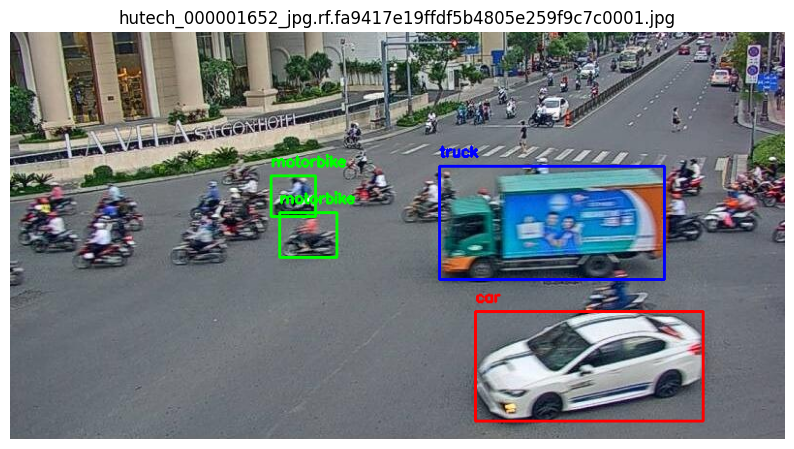

Visualizing UA-DETRAC Train Sample:


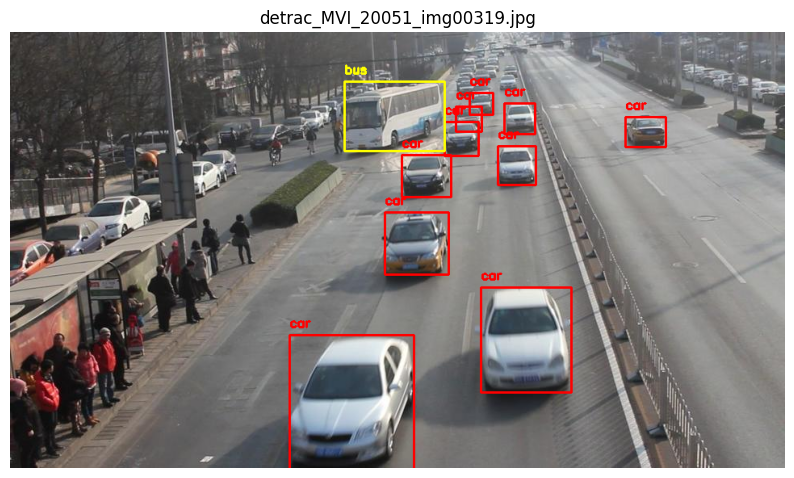

In [5]:
# Display random samples from Train split (HUTECH and UA-DETRAC)
train_img_dir = os.path.join(dataset_dir, 'train', 'images')
train_lbl_dir = os.path.join(dataset_dir, 'train', 'labels')

# Find HUTECH samples
hutech_images = [f for f in os.listdir(train_img_dir) if f.startswith('hutech_')]
if hutech_images:
    sample_img = random.choice(hutech_images)
    name_no_ext, _ = os.path.splitext(sample_img)
    img_path = os.path.join(train_img_dir, sample_img)
    lbl_path = os.path.join(train_lbl_dir, f'{name_no_ext}.txt')
    print('Visualizing HUTECH Train Sample:')
    plot_sample(img_path, lbl_path)

# Find UA-DETRAC samples
detrac_images = [f for f in os.listdir(train_img_dir) if f.startswith('detrac_')]
if detrac_images:
    sample_img = random.choice(detrac_images)
    name_no_ext, _ = os.path.splitext(sample_img)
    img_path = os.path.join(train_img_dir, sample_img)
    lbl_path = os.path.join(train_lbl_dir, f'{name_no_ext}.txt')
    print('Visualizing UA-DETRAC Train Sample:')
    plot_sample(img_path, lbl_path)